# 05 · 새로 측정한 latency 위의 importance–latency 비교

## 목적

실험 02의 결과를 불러오지 않는다. 이 노트북이 직접 생성한 새 파일에서 $T$를 다시 측정하고, 새 importance 입력에 대해 여러 selector가 만든 mask를 같은 좌표계에 놓는다.

$$x(M)=\widehat L(M)=\sum_{C\in\mathcal R(M)}\widehat T(|C|),\qquad
y(M)=I(M)/I(\mathbf1).$$

$x$는 새 실측 table을 합산한 **예측 I/O**이며 mask 전체를 직접 잰 wall time은 아니다. 실제 mask time 비교는 07이다. $y$는 retained importance이며 task accuracy는 아니다. synthetic importance는 synthetic이라고 명시한다.

## 설계

$n=1024$개의 4 KiB 행, flat·smooth·spiky 세 입력을 사용한다. 512 MiB 새 파일에서 4 KiB–8 MiB의 chunk를 측정한다. 원본 채널 가중치 크기를 흉내 낸 숨은 단위 변환은 없다. 측정 grid 안에서는 선형 보간하고 grid 밖에는 외삽하지 않는다. $s=s_{.05}$는 새 curve에서 선택한 near-best 길이다. finite grid의 near-best 기준을 수학적 포화점으로 확정하지 않는다.

Top-$R$, dense Algorithm 1, shifted saturation tiles는 같은 $R$ sweep을 사용한다. 비율 정확해는 $|M|\le R$로 별도 표시한다. 일반 table DP의 $\lambda$ sweep은 다른 objective에서 얻은 supported point들을 추가한다. 공집합과 전체 mask를 포함하여 양 끝의 feasibility를 드러낸다.

## 같은 quality에서의 비교

방법 $A$의 실제 생성 mask 집합을 $\mathcal C_A$라 할 때

$$\widehat L_A(q)=\min_{M\in\mathcal C_A:\ I(M)\ge qI(\mathbf1)}\widehat L(M).$$

feasible mask가 없으면 NaN이다. 두 점을 연결해 그린 선은 시각화용일 뿐, 이 계산에는 보간을 사용하지 않는다. $q\in\{.25,.5,.75,.9\}$를 사전에 고정한다. 원래의 global constrained optimum이 아니라 **평가한 candidate 집합 안에서의 최선**이다.

$$\Delta_q(A,P)=100\left(1-\frac{\widehat L_A(q)}{\widehat L_P(q)}\right).$$

양수는 같은 importance 하한에서 $A$의 예측 latency가 작다는 뜻이다. 이 값과 함께 실제 달성 importance와 선택 행 수를 저장하여 서로 다른 overshoot를 확인할 수 있게 한다.

## 곡선 오차가 선택에 미치는 영향

각 run에 대해 $|T(\ell)-\hat T(\ell)|\le\epsilon$이면

$$|L_T(M)-L_{\hat T}(M)|\le K(M)\epsilon,\qquad K(M)=|\mathcal R(M)|.$$

따라서 fragmented mask는 같은 per-run 오차를 더 많이 누적할 수 있다. 상대오차 $|T/\hat T-1|\le\eta$가 모든 사용 길이에 성립하면 $(1-\eta)\hat L\le L\le(1+\eta)\hat L$. 하지만 실측 일부 길이에서의 fit 오차만으로 이 uniform bound가 성립했다고 간주할 수 없다.

## 보고서의 출력

각 입력의 importance 곡선, latency–importance cloud와 방법별 attainable envelope, 같은 quality의 latency table, 대표 mask heatmap을 생성한다. raw I/O·모든 candidate point·mask를 저장한다. 새 machine에서 성능 순위가 바뀌어도 실험의 실패로 처리하지 않는다. 이는 확인할 사실이다.


## 실행 설정과 provenance

Run All은 새로운 계산·측정을 수행하고 고유 run 디렉토리를 만듭니다.

In [1]:
from pathlib import Path
import json
import sys
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p / "conclusion_september" for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "conclusion_september/core.py").exists())
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
rng = np.random.default_rng(SEED)
RUN = begin(ROOT, "05_measured_frontier", SEED)

**이번 실행:** `05_measured_frontier-20260926T043643-6c5cc338` · seed `20260926` · 새 계산/측정

## 측정과 입력 · 다른 노트북 결과를 읽지 않는 fresh calibration

In [2]:
from measure import profile, cost_table, near_saturation
n = 1024
raw, hardware = profile(RUN, repeats=5, seed=SEED)
raw.to_csv(RUN / "io_raw.csv", index=False)
(RUN / "hardware.json").write_text(json.dumps(hardware, indent=2))
cost = cost_table(raw, n)
s = near_saturation(raw)
budgets = np.unique(np.r_[0, np.linspace(16, n, 13, dtype=int)])
records, all_masks, signals = [], {}, {}
for kind in ["flat", "smooth", "spiky"]:
    v = C.workload(n, SEED, kind)
    signals[kind] = v
    for r in budgets:
        methods = {"Top-R": C.topk(v, r), "Paper": C.paper(v, r, cost, s),
                   "Saturation": C.saturation(v, r, cost, s), "Ratio exact": C.ratio_opt(v, r, cost)}
        for method, mask in methods.items():
            key = f"{kind}|{method}|R{r}"
            all_masks[key] = mask
            records.append(dict(key=key, kind=kind, method=method, R=int(r),
                                selected=int(mask.sum()), latency=C.latency(mask, cost), retained=v[mask].sum()/v.sum()))
    for index, penalty in enumerate(np.r_[0, np.geomspace(.01, 100, 36) * v.sum() / cost[n]]):
        mask = C.lagrangian(v / v.sum(), cost, penalty / v.sum())
        key = f"{kind}|Scalar DP|lambda{index}"
        all_masks[key] = mask
        records.append(dict(key=key, kind=kind, method="Scalar DP", R=np.nan,
                            selected=int(mask.sum()), latency=C.latency(mask, cost), retained=v[mask].sum()/v.sum()))
frame = pd.DataFrame(records)
frame.to_csv(RUN / "candidates.csv", index=False)
np.savez_compressed(RUN / "masks.npz", **all_masks)
comparison = []
for (kind, method), group in frame.groupby(["kind", "method"]):
    for q in [.25, .5, .75, .9]:
        feasible = group[group.retained >= q - 1e-12]
        point = feasible.loc[feasible.latency.idxmin()] if len(feasible) else None
        comparison.append(dict(kind=kind, method=method, target=q,
                               latency=np.nan if point is None else point.latency,
                               achieved=np.nan if point is None else point.retained,
                               selected=np.nan if point is None else point.selected))
matched = pd.DataFrame(comparison)
matched.to_csv(RUN / "matched_quality.csv", index=False)
display(matched.pivot_table(index=["kind", "target"], columns="method", values="latency", dropna=False).round(4))

method          Paper  Ratio exact  Saturation  Scalar DP   Top-R
kind   target                                                    
flat   0.25    0.2041       0.2041      0.2041     0.6136  0.2041
       0.50    0.3167       0.3167      0.3167     0.6136  0.3167
       0.75    0.4650       0.4650      0.4650     0.6136  0.4650
       0.90    0.5641       0.5641      0.5641     0.6136  0.5641
smooth 0.25    0.2326       0.2326      0.2041     0.5434  0.6136
       0.50    0.3677       0.3661      0.3434     0.5434  0.6136
       0.75    0.5935          NaN      0.5134     0.5434  0.6136
       0.90    0.6136          NaN      0.5641     0.5434  0.6136
spiky  0.25    0.2058          NaN      0.2041     0.5617  0.6136
       0.50    0.3735          NaN      0.3167     0.5617  0.6136
       0.75    0.5568          NaN      0.5134     0.5617  0.6136
       0.90    0.6136          NaN      0.5790     0.5617  0.6136

## 관측 · 각 방법의 attainable envelope와 대표 mask

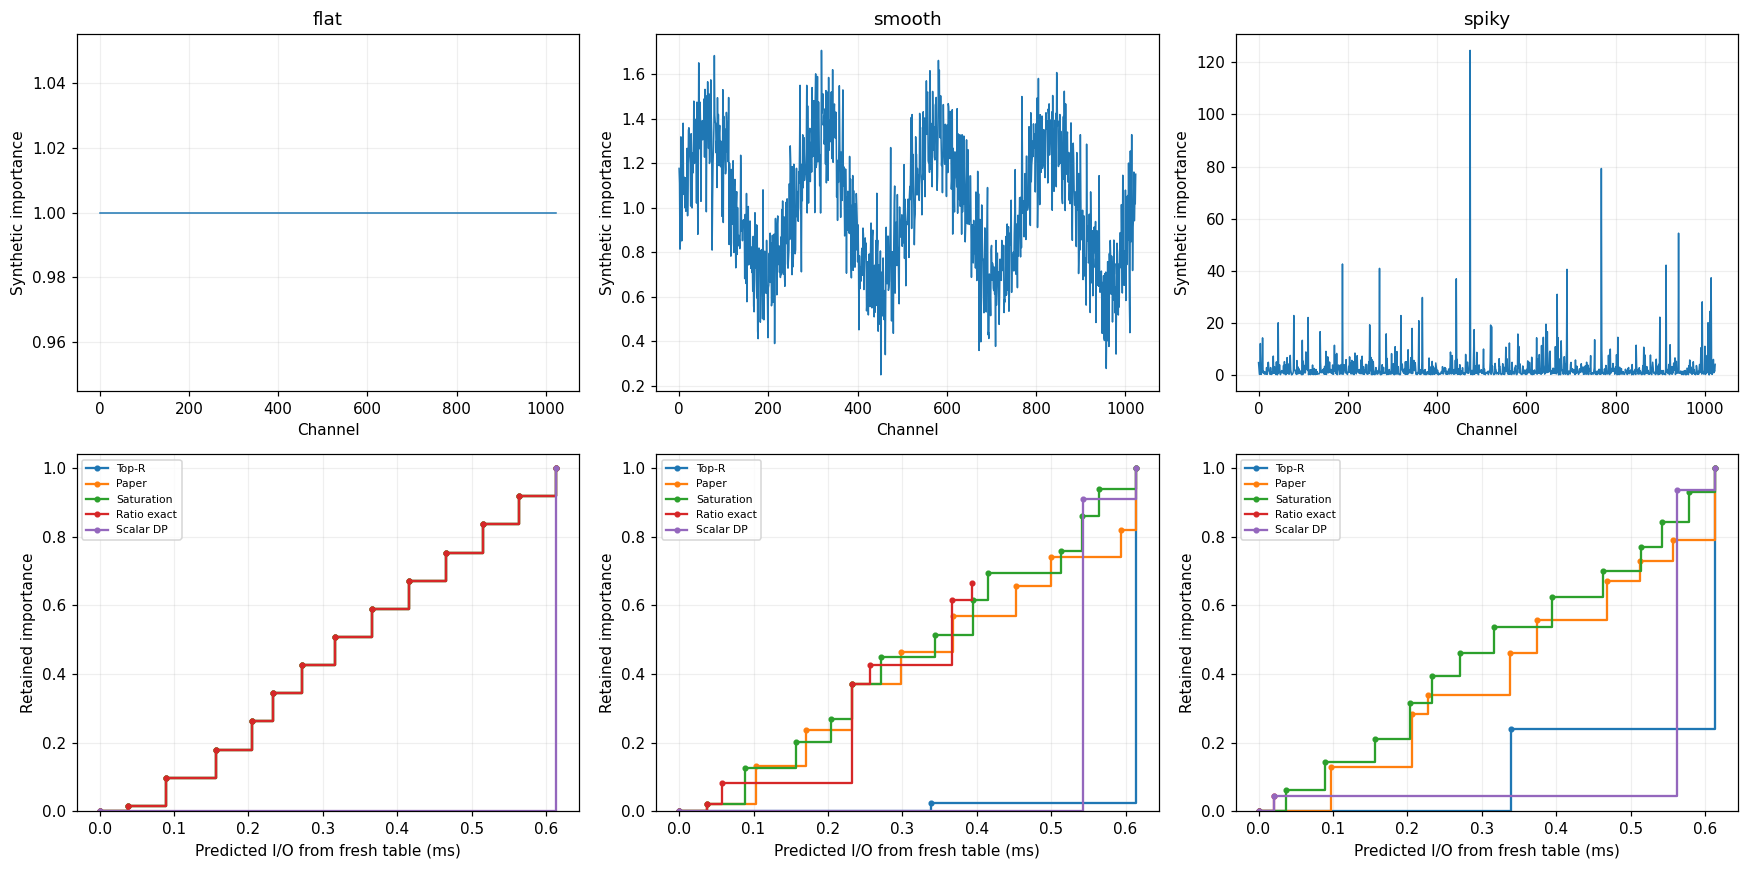

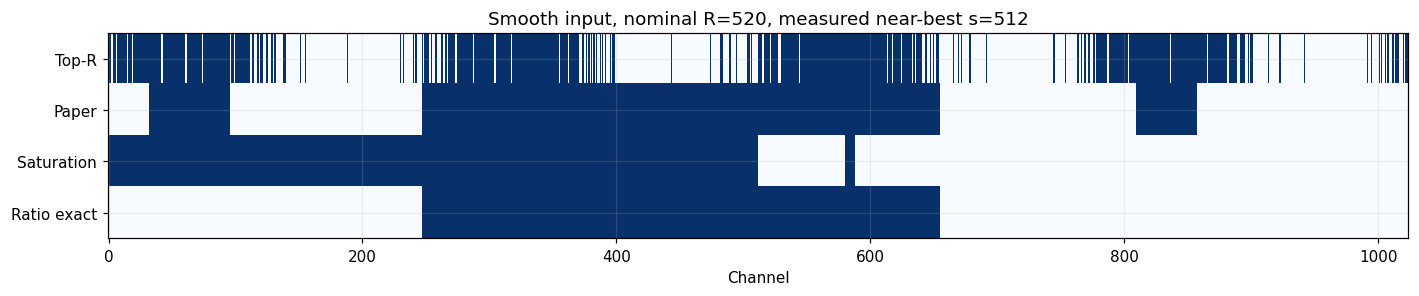

**실행에서 확인한 값**

- **near_best_length_pages**: 512

- **measured_max_pages**: 2048

- **candidates**: 279

- **feasible_comparisons**: 54

- **scope**: Fresh device profile + synthetic importance; curves are model predictions, not mask wall time

- **completed_utc**: 2026-09-26T04:37:01.892429+00:00

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for column, kind in enumerate(signals):
    axes[0, column].plot(signals[kind], lw=1)
    axes[0, column].set(title=kind, xlabel="Channel", ylabel="Synthetic importance")
    for method, group in frame[frame.kind == kind].groupby("method", sort=False):
        indices = C.frontier(group.retained.to_numpy(), group.latency.to_numpy())
        edge = group.iloc[indices]
        axes[1, column].step(edge.latency, edge.retained, where="post", marker=".", label=method)
    axes[1, column].set(xlabel="Predicted I/O from fresh table (ms)", ylabel="Retained importance", ylim=(0, 1.04))
    axes[1, column].legend(fontsize=7)
figure(RUN, "measured_table_frontiers")
example_r = int(budgets[len(budgets) // 2])
keys = [f"smooth|{method}|R{example_r}" for method in ["Top-R", "Paper", "Saturation", "Ratio exact"]]
plt.figure(figsize=(13, 2.8))
plt.imshow(np.array([all_masks[key] for key in keys]), aspect="auto", cmap="Blues", interpolation="nearest")
plt.yticks(range(len(keys)), [key.split("|")[1] for key in keys])
plt.xlabel("Channel")
plt.title(f"Smooth input, nominal R={example_r}, measured near-best s={s}")
figure(RUN, "mask_geometry")
finish(RUN, near_best_length_pages=s, measured_max_pages=int(raw.length.max()),
       candidates=len(frame), feasible_comparisons=int(matched.latency.notna().sum()),
       scope="Fresh device profile + synthetic importance; curves are model predictions, not mask wall time")